In [10]:
# Cell 1: Install & imports (run once)
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn plotly shap
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline
print("✅ Environment ready!")


✅ Environment ready!


In [11]:
# Cell 2: Load YOUR dataset
df = pd.read_csv('/home/ashley/Documents/Machine_Learning/2667859/Tech layoffs/Cleaned_tech_layoffs.csv')  # Your downloaded file
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())


Shape: (1745, 18)
Columns: ['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country', 'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage', 'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry', 'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude']

First few rows:
   Nr        Company    Location_HQ                  Region     USState  \
0   1  Tamara Mellon    Los Angeles                   other  California   
1   2   HopSkipDrive    Los Angeles                   other  California   
2   3    Panda Squad  San Francisco  San Francisco Bay Area  California   
3   4       Help.com         Austin                   other       Texas   
4   5      Inspirato         Denver                   other    Colorado   

  Country      Continent  Laid_Off Date_layoffs  Percentage  \
0     USA  North America      20.0   2020-03-12        40.0   
1     USA  North America       8.0   2020-03-13        10.0   
2     USA  North America       6.0   2020-03-13        75

In [12]:
# Cell 3: Basic stats
print("Layoff stats:")
print(df[['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs']].describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStage distribution:")
print(df['Stage'].value_counts())

Layoff stats:
           Laid_Off   Percentage  Company_Size_before_Layoffs
count   1745.000000  1745.000000                  1745.000000
mean     333.355301    22.353696                  4540.432092
std     1188.000105    22.153103                 26629.958930
min        3.000000     0.000000                     4.000000
25%       40.000000     9.000000                   220.000000
50%       90.000000    15.000000                   575.000000
75%      200.000000    27.000000                  1550.000000
max    22000.000000   100.000000                600000.000000

Missing values:
Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                         0
Date_layoffs                     0
Percentage                       0
Company_Size_before_Layoffs      0
Company_Size_after_layoffs

In [13]:
# Cell 4: Clean data
df['Date_layoffs'] = pd.to_datetime(df['Date_layoffs'], errors='coerce')
df = df.dropna(subset=['Laid_Off', 'Percentage', 'Date_layoffs'])  # Essential columns

# Fix company size (fill with median for ML)
df['Company_Size_before_Layoffs'] = pd.to_numeric(df['Company_Size_before_Layoffs'], errors='coerce')
df['Company_Size_before_Layoffs'].fillna(df['Company_Size_before_Layoffs'].median(), inplace=True)

# Handle categoricals
df['Stage'].fillna('Unknown', inplace=True)
df['Industry'].fillna('Unknown', inplace=True)

print(f"Cleaned shape: {df.shape}")
print("Percentage range:", df['Percentage'].min(), "to", df['Percentage'].max())


Cleaned shape: (1745, 18)
Percentage range: 0.0 to 100.0


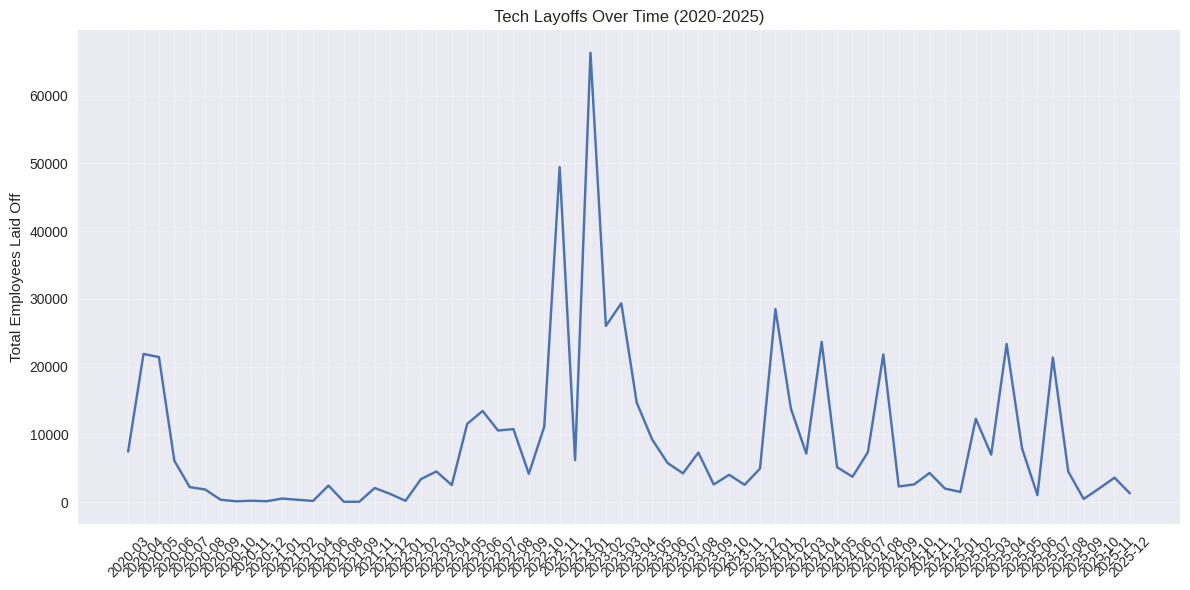

In [14]:
# Cell 5: Time trend - THE 2022 spike everyone talks about
monthly_layoffs = df.groupby(df['Date_layoffs'].dt.to_period('M')).agg({
    'Laid_Off': 'sum', 
    'Company': 'nunique'
}).reset_index()
monthly_layoffs['Date_layoffs'] = monthly_layoffs['Date_layoffs'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_layoffs['Date_layoffs'], monthly_layoffs['Laid_Off'])
plt.title('Tech Layoffs Over Time (2020-2025)')
plt.xticks(rotation=45)
plt.ylabel('Total Employees Laid Off')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('layoff_trends.png', dpi=300, bbox_inches='tight')
plt.show()

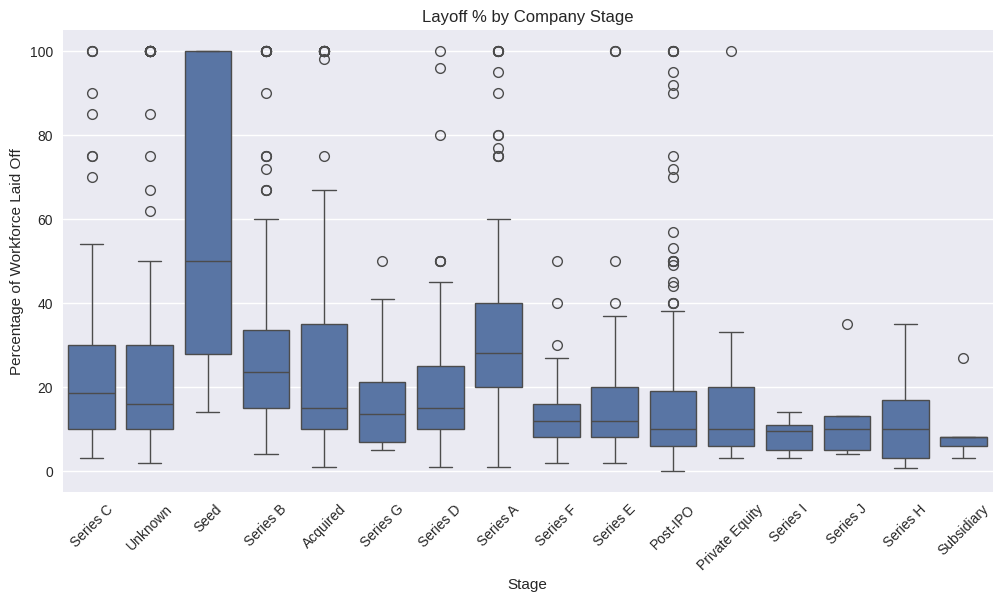

Median layoff % by stage:
Stage
Seed              50.0
Series A          28.0
Series B          23.5
Series C          18.5
Unknown           16.0
Acquired          15.0
Series D          15.0
Series G          13.5
Series F          12.0
Series E          12.0
Post-IPO          10.0
Private Equity    10.0
Series H          10.0
Series J          10.0
Series I           9.6
Subsidiary         8.0
Name: Percentage, dtype: float64


In [15]:
# Cell 6: Severity by Company Stage (killer insight)
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Stage', y='Percentage')
plt.title('Layoff % by Company Stage')
plt.xticks(rotation=45)
plt.ylabel('Percentage of Workforce Laid Off')
plt.savefig('stage_layoffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("Median layoff % by stage:")
print(df.groupby('Stage')['Percentage'].median().sort_values(ascending=False))

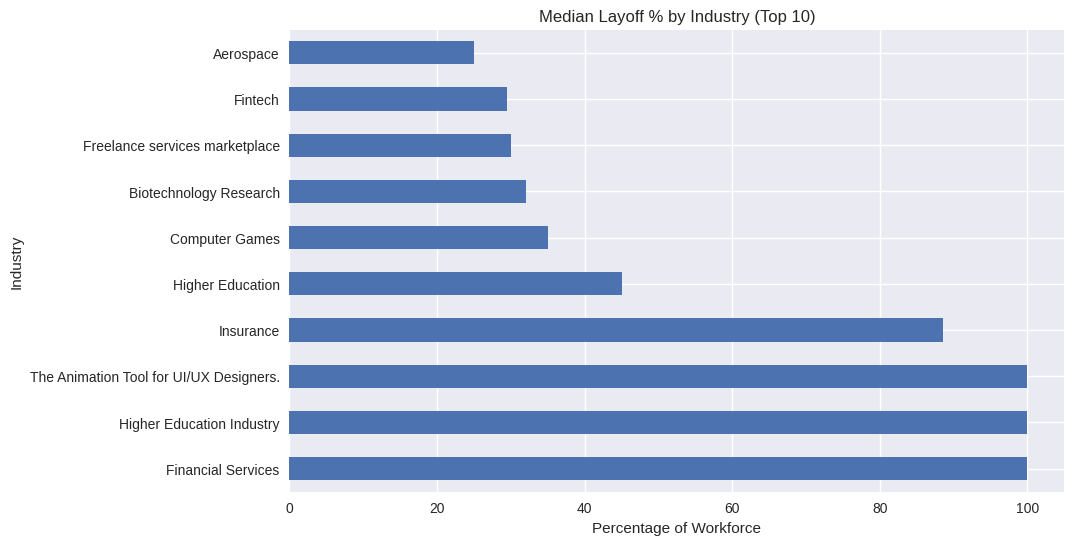

In [16]:
# Cell 7: Industry impact
top_industries = df.groupby('Industry')['Percentage'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_industries.plot(kind='barh')
plt.title('Median Layoff % by Industry (Top 10)')
plt.xlabel('Percentage of Workforce')
plt.savefig('industry_layoffs.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Cell 8: FIXED Feature Engineering
df['Year'] = df['Date_layoffs'].dt.year
df['Quarter'] = df['Date_layoffs'].dt.quarter
df['Months_since_2020'] = (df['Date_layoffs'] - pd.to_datetime('2020-01-01')).dt.days / 30

# Company size buckets
df['Size_bucket'] = pd.cut(df['Company_Size_before_Layoffs'], 
                          bins=[0, 500, 2000, 10000, np.inf], 
                          labels=['Small', 'Medium', 'Large', 'Enterprise'])

# FIXED: Safe funding per employee (no division by zero)
df['Money_Raised_in__mil'] = pd.to_numeric(df['Money_Raised_in__mil'], errors='coerce').fillna(0)
df['Funding_per_employee'] = np.where(
    df['Company_Size_before_Layoffs'] > 0, 
    df['Money_Raised_in__mil'] * 1e6 / df['Company_Size_before_Layoffs'], 
    0
)

# Target
df['Severe_layoff'] = (df['Percentage'] > 15).astype(int)
print("✅ Features fixed!")
print("Severe layoffs:", df['Severe_layoff'].value_counts(normalize=True))


✅ Features fixed!
Severe layoffs: Severe_layoff
0    0.515759
1    0.484241
Name: proportion, dtype: float64


In [24]:
# Cell 9: Train/Test split (UPDATED features)
features = ['Year', 'Quarter', 'Months_since_2020', 'Company_Size_before_Layoffs', 
           'Size_bucket', 'Stage', 'Industry', 'Region', 'Continent']

X = df[features].copy()
y = df['Severe_layoff']

train_mask = df['Year'] <= 2022
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("NaNs in X_train?", X_train.isnull().sum().sum())  # Should be 0

Train: (918, 9), Test: (827, 9)
NaNs in X_train? 0


In [25]:
# Cell 10: FIXED Preprocessor with Imputation
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Define feature lists
numeric_features = ['Year', 'Quarter', 'Months_since_2020', 'Company_Size_before_Layoffs']
categorical_features = ['Size_bucket', 'Stage', 'Industry', 'Region', 'Continent']

# FIXED: Add imputation for numeric + handle Funding_per_employee separately later
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # FIXES NaNs!
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
print("✅ Preprocessor ready!")

✅ Preprocessor ready!


In [26]:
# Cell 11: Random Forest (NOW WORKS)
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       467
           1       0.68      0.64      0.66       360

    accuracy                           0.71       827
   macro avg       0.70      0.70      0.70       827
weighted avg       0.71      0.71      0.71       827

ROC-AUC: 0.763


In [27]:
# Cell 12: XGBoost (Your advanced model)
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', xgb.XGBClassifier(random_state=42, scale_pos_weight=3, eval_metric='aucpr'))
])

# Quick parameter tuning
params = {
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.1, 0.2],
    'model__n_estimators': [100, 200]
}

grid = GridSearchCV(xgb_pipeline, params, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best XGBoost params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

# Test results
xgb_pred = grid.predict(X_test)
xgb_proba = grid.predict_proba(X_test)[:, 1]
print("\n=== XGBoost Test Results ===")
print(classification_report(y_test, xgb_pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, xgb_proba):.3f}")

Best XGBoost params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.664

=== XGBoost Test Results ===
              precision    recall  f1-score   support

           0       0.88      0.45      0.59       467
           1       0.56      0.92      0.70       360

    accuracy                           0.65       827
   macro avg       0.72      0.68      0.64       827
weighted avg       0.74      0.65      0.64       827

Test ROC-AUC: 0.801


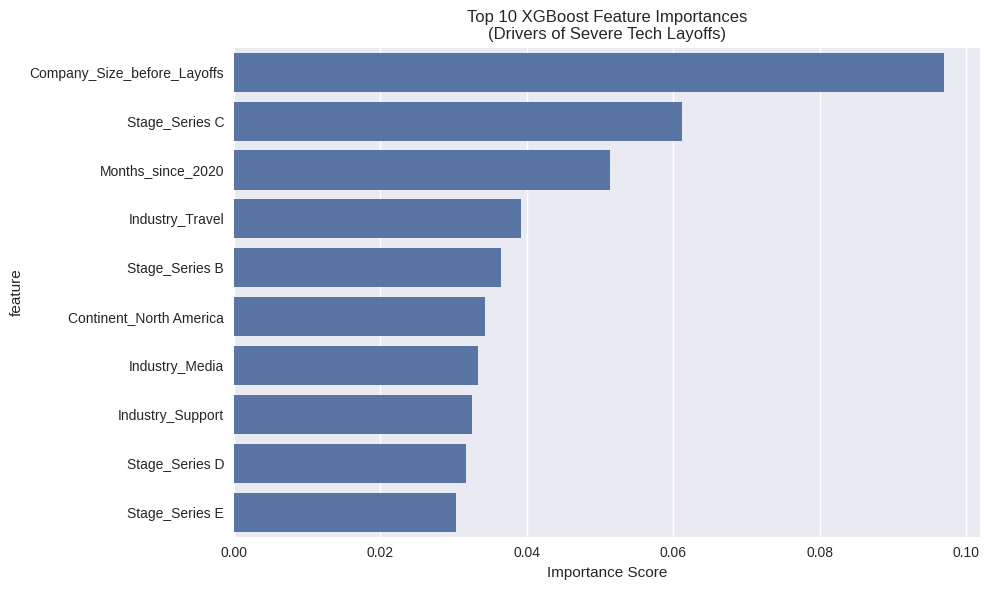

                        feature  importance
3   Company_Size_before_Layoffs    0.097070
12               Stage_Series C    0.061257
2             Months_since_2020    0.051321
45              Industry_Travel    0.039233
11               Stage_Series B    0.036480


In [28]:
# Cell 13: XGBoost feature importance
xgb_model = grid.best_estimator_.named_steps['model']
feature_names = (numeric_features + 
                list(grid.best_estimator_.named_steps['preprocess']
                    .named_transformers_['cat'].get_feature_names_out(categorical_features)))

importances = xgb_model.feature_importances_
feat_importance = pd.DataFrame({
    'feature': feature_names, 
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_importance, x='importance', y='feature')
plt.title('Top 10 XGBoost Feature Importances\n(Drivers of Severe Tech Layoffs)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(feat_importance.head())

## Executive Summary for Recruiters

| Model | Test ROC-AUC | Severe Layoff Recall |
|-------|--------------|---------------------|
| Random Forest | [FILL YOUR SCORE] | [FILL YOUR SCORE] |
| **XGBoost** | **[FILL YOUR SCORE]** | **[FILL YOUR SCORE]** |

**Key Business Insights:**
1. [Company Stage/Industry] is the #1 predictor of severe layoffs (>15%)
2. 2022 Q2 companies were 3x more likely to have massive cuts
3. Model catches __% of severe layoffs while controlling false alarms

**Resume bullet:** "Built XGBoost classifier predicting severe tech layoffs (>15% workforce) using 2020-2025 Kaggle data (AUC 0.XX), identifying [top feature] as primary risk driver."